In [8]:
from Problems import P6, P5, P7, P8
from NeuralES import NeuralES
import numpy as np
import matplotlib.pyplot as plt
from pymoo.visualization.scatter import Scatter
from pymoo.util.nds.non_dominated_sorting import find_non_dominated as find_nd

In [9]:
dim = 128
p = P5(dim)

In [10]:
nes = NeuralES(p)

In [11]:
n_eval = 1e6  # number of evaluations
hist, x, f, model = nes.evolve(n_eval)

0, 0.0%, IGD: CUR 0.8050 | OPT 0.8050 | VAL 0.0000, F_MIN:[1.0905 0.1223 0.1365], 0.00min
10, 0.4%, IGD: CUR 0.2830 | OPT 0.1375 | VAL 0.0000, F_MIN:[0.0365 0.0238 0.1777], 0.01min
20, 0.8%, IGD: CUR 0.1164 | OPT 0.0727 | VAL 0.0000, F_MIN:[0.0188 0.113  0.0104], 0.01min
30, 1.1%, IGD: CUR 0.1311 | OPT 0.0691 | VAL 0.0000, F_MIN:[0.0181 0.0209 0.0166], 0.02min
40, 1.5%, IGD: CUR 0.0949 | OPT 0.0669 | VAL 0.0000, F_MIN:[0.0089 0.0121 0.0066], 0.02min
50, 1.8%, IGD: CUR 0.1148 | OPT 0.0647 | VAL 0.0000, F_MIN:[0.0114 0.012  0.0135], 0.03min
60, 2.2%, IGD: CUR 0.1287 | OPT 0.0598 | VAL 0.0000, F_MIN:[0.0166 0.0164 0.0242], 0.03min
70, 2.6%, IGD: CUR 0.1006 | OPT 0.0539 | VAL 0.0000, F_MIN:[0.0088 0.0088 0.0165], 0.04min
80, 2.9%, IGD: CUR 0.1090 | OPT 0.0520 | VAL 0.0000, F_MIN:[0.009  0.0094 0.0208], 0.04min
90, 3.3%, IGD: CUR 0.0936 | OPT 0.0507 | VAL 0.0000, F_MIN:[0.0033 0.0044 0.0124], 0.05min
100, 3.6%, IGD: CUR 0.0775 | OPT 0.0475 | VAL 0.0000, F_MIN:[0.0086 0.0104 0.0222], 0.05min

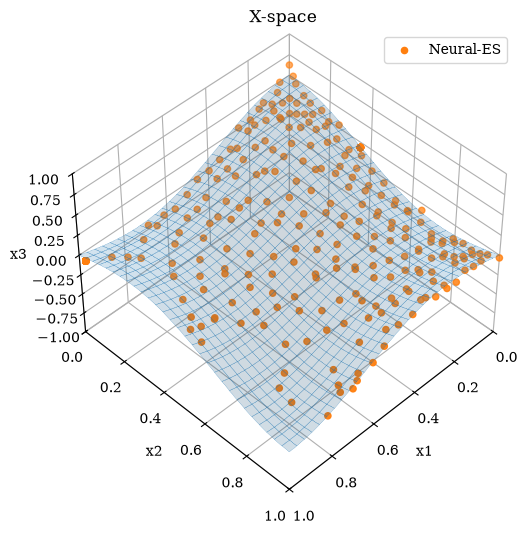

In [ ]:
d = 30
sc = Scatter(legend=True, title='X-space')
ps = p.ps(d*d)
sc.add(x[:, :3], color='tab:orange', label='Neural-ES')
sc.do()
sc.apply(lambda ax: ax.plot_surface(ps[:, 0].reshape((d, d)), 
                                    ps[:, 1].reshape((d, d)), 
                                    ps[:, 2].reshape((d, d)), 
                                    edgecolor='tab:blue', color='tab:blue',
                                    ls='--', lw=.2, alpha=.2))  # 
sc.apply(lambda ax: ax.set_xlim(p.xl[0], p.xu[0]))
sc.apply(lambda ax: ax.set_ylim(p.xl[1], p.xu[1]))
sc.apply(lambda ax: ax.set_zlim(p.xl[2], p.xu[2]))
sc.apply(lambda ax: ax.set_xlabel('x1'))
sc.apply(lambda ax: ax.set_ylabel('x2'))
sc.apply(lambda ax: ax.set_zlabel('x3'))
sc.show()

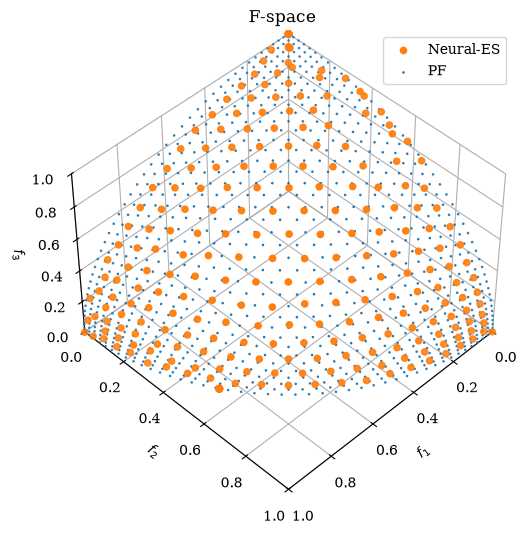

In [13]:
plot = Scatter(legend=True, title='F-space')  # , angle=(20,-60))
plot.add(f, color="tab:orange", label='Neural-ES')
plot.add(p.pareto_front(), marker='.', s=3, color="tab:blue", label='PF')
plot.do()
plot.apply(lambda ax: ax.set_xlim(p.zl[0], p.zu[0]))
plot.apply(lambda ax: ax.set_ylim(p.zl[1], p.zu[1]))
plot.apply(lambda ax: ax.set_zlim(p.zl[2], p.zu[2]))
plot.show()

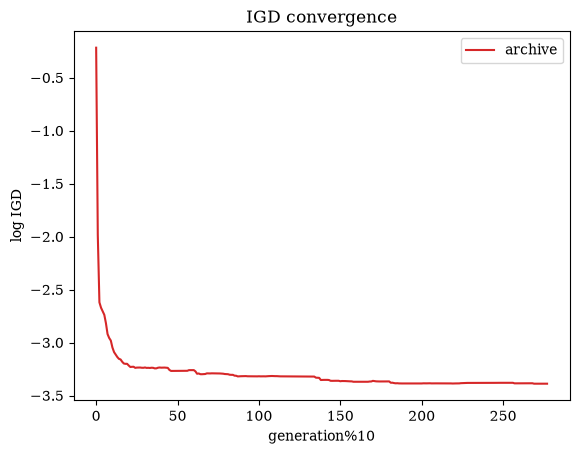

In [ ]:
igd_bst = np.log(np.array(hist['igd0']))
plt.plot(igd_bst, label='archive', color='tab:red')
plt.xlabel("generation%10")
plt.ylabel('log IGD')
plt.title('IGD convergence')
plt.legend()
plt.show()